# Model Comparison

Comparison of multiple machine learning algorithms for binary intrusion detection.

## Objective

Evaluate and compare different machine learning algorithms for binary intrusion detection on the NSL-KDD dataset.

In [45]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import time
import joblib

In [46]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted",
    "num_root","num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate",
    "srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

train = pd.read_csv(
    "../data/raw/KDDTrain+.txt",
    names=columns
)

test = pd.read_csv(
    "../data/raw/KDDTest+.txt",
    names=columns
)

print(train.head())
print(test.head())
print(train.shape)


   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [47]:
train["binary_label"] = train["label"].apply(lambda x: 0 if x == "normal" else 1)

test["binary_label"] = test["label"].apply(lambda x: 0 if x == "normal" else 1)

In [48]:
X_train = train.drop(columns=["label", "binary_label", "difficulty"])
X_test = test.drop(columns=["label", "binary_label", "difficulty"])

y_train = train["binary_label"]
y_test = test["binary_label"]

In [49]:
preprocessor = joblib.load("../models/preprocessor.pkl")

In [50]:
results = []

def evaluate_model(name, model):
    start = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = None

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "Train Time (s)": train_time
    })

    print(f"\n{name}")
    print("="*50)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(classification_report(y_test, y_pred))

In [51]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

evaluate_model("Logistic Regression", lr_pipeline)


Logistic Regression
Accuracy : 0.7432
ROC-AUC  : 0.8797
              precision    recall  f1-score   support

           0       0.64      0.92      0.76      9711
           1       0.91      0.61      0.73     12833

    accuracy                           0.74     22544
   macro avg       0.78      0.77      0.74     22544
weighted avg       0.80      0.74      0.74     22544



/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [52]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

evaluate_model("Decision Tree", dt_pipeline)


Decision Tree
Accuracy : 0.8151
ROC-AUC  : 0.8331
              precision    recall  f1-score   support

           0       0.71      0.96      0.82      9711
           1       0.96      0.70      0.81     12833

    accuracy                           0.82     22544
   macro avg       0.84      0.83      0.82     22544
weighted avg       0.85      0.82      0.81     22544



In [53]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

evaluate_model("Random Forest", rf_pipeline)


Random Forest
Accuracy : 0.7776
ROC-AUC  : 0.9619
              precision    recall  f1-score   support

           0       0.67      0.97      0.79      9711
           1       0.97      0.63      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.77     22544



In [54]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="logloss"
    ))
])

evaluate_model("XGBoost", xgb_pipeline)


XGBoost
Accuracy : 0.7935
ROC-AUC  : 0.9646
              precision    recall  f1-score   support

           0       0.68      0.97      0.80      9711
           1       0.97      0.66      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.83      0.82      0.79     22544
weighted avg       0.85      0.79      0.79     22544



In [55]:
lgbm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42,
        verbose=-1
    ))
])

evaluate_model("LightGBM", lgbm_pipeline)


LightGBM
Accuracy : 0.7821
ROC-AUC  : 0.9611
              precision    recall  f1-score   support

           0       0.67      0.97      0.79      9711
           1       0.97      0.64      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.81      0.78     22544
weighted avg       0.84      0.78      0.78     22544



/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [56]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df = results_df.round(4)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Train Time (s)
0,Decision Tree,0.8151,0.9599,0.7047,0.8127,0.8331,0.8138
1,XGBoost,0.7935,0.9684,0.6587,0.7841,0.9646,1.0236
2,LightGBM,0.7821,0.9679,0.6384,0.7693,0.9611,1.2925
3,Random Forest,0.7776,0.9688,0.6295,0.7632,0.9619,2.3527
4,Logistic Regression,0.7432,0.9142,0.6058,0.7287,0.8797,6.5618


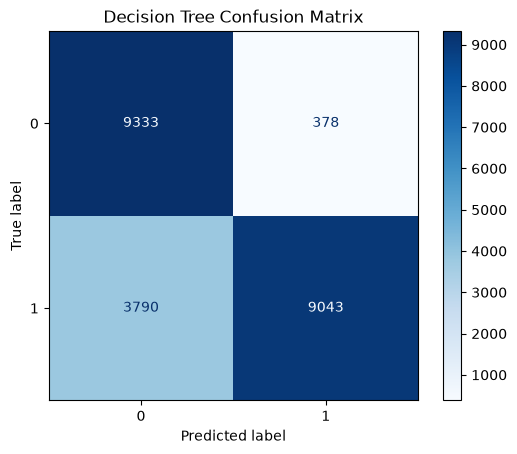

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    dt_pipeline,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [58]:
results_df.to_csv(
    "../reports/model_comparison.csv",
    index=False
)